### Generate Websky 90 - 220 GHz Maps with noise or smoothing the maps

In [20]:
import time
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Here in webskymaker i've generated CMB, tSZ, and kSZ components outside the create function so that the function wouldn't
# take as long.
from webskymaker import create_websky_map, generate_coords
from pixell import enmap, utils, reproject
from pixell.enmap import ndmap, fft, ifft
path = "/mnt/welch/USERS/cwhitaker/maps/websky/"
#path = "/scratch/jorlo/websky/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
coords = generate_coords()

In [4]:
t0 = time.time()
webskyf090map = create_websky_map(path=path, freq="220", noise=20)
t1 = time.time()
print(t1 - t0)

106.3788275718689


In [16]:
websky090 = reproject.thumbnails(webskyf090map, coords[0], r = 2 * utils.degree)

In [25]:
def smooth_gauss(emap, sigma):
    """
    Smooth the map given as the first argument with a gaussian beam
    with the given standard deviation sigma in radians.
    """
    if np.all(sigma == 0): return emap.copy()
    f  = fft(emap)
    x2 = np.sum(emap.lmap()**2*sigma**2,0)
    if sigma >= 0: f *= np.exp(-0.5*x2)
    else:          f *= 1-np.exp(-0.5*x2)
    return enmap.enmap(ifft(f).real, emap.wcs)
def fwhm_to_sigma(fwhm):
    # Converts fwhm arcmins to sigma radians
    return fwhm / (2.*np.sqrt(2.*np.log(2.))) * (np.pi / (180.*60.))
    
print(fwhm_to_sigma(fwhm=2.2))
smoothweb = smooth_gauss(websky090, fwhm_to_sigma(2.2))

0.0002717634667731804


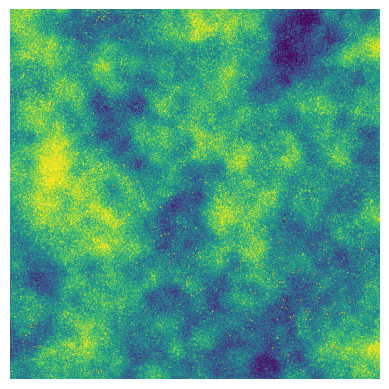

In [22]:
lims=300
plt.imshow(websky090, vmin=-lims, vmax=lims)
plt.axis(False);

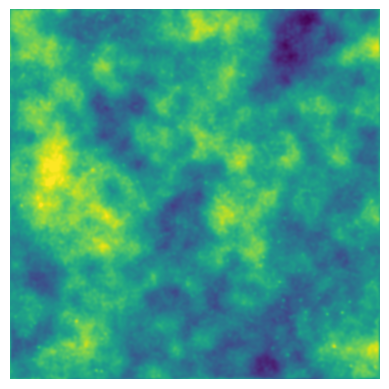

In [23]:
lims=300
plt.imshow(smoothweb, vmin=-lims, vmax=lims)
plt.axis(False);